In [ ]:
from google.colab import files
uploaded = files.upload()

Saving career_dataset_large.xlsx to career_dataset_large (1).xlsx


In [ ]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [ ]:
print(df.columns)

Index(['Education Level', 'Specialization', 'Skills', 'Certifications',
       'CGPA/Percentage', 'Recommended Career'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
Education Level,0
Specialization,0
Skills,0
Certifications,596
CGPA/Percentage,0
Recommended Career,0


EDA

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

Shape: (5000, 6)

Columns:
 Index(['Education Level', 'Specialization', 'Skills', 'Certifications',
       'CGPA/Percentage', 'Recommended Career'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Education Level     5000 non-null   object
 1   Specialization      5000 non-null   object
 2   Skills              5000 non-null   object
 3   Certifications      4404 non-null   object
 4   CGPA/Percentage     5000 non-null   int64 
 5   Recommended Career  5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


since the certificate has null value, and other certificate values are numeric . we replace the null value with 0

In [ ]:
df["Certifications"] = df["Certifications"].fillna(0)

In [ ]:
df["Certifications"].isnull().sum()

np.int64(0)

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

Shape: (5000, 6)

Columns:
 Index(['Education Level', 'Specialization', 'Skills', 'Certifications',
       'CGPA/Percentage', 'Recommended Career'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Education Level     5000 non-null   object
 1   Specialization      5000 non-null   object
 2   Skills              5000 non-null   object
 3   Certifications      5000 non-null   object
 4   CGPA/Percentage     5000 non-null   int64 
 5   Recommended Career  5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


checking unique values in the dataset

In [ ]:
print("Education Levels:", df["Education Level"].unique())
print("Specializations:", df["Specialization"].unique())
print("Careers:", df["Recommended Career"].unique())

Education Levels: ["Bachelor's" 'Intermediate' "Master's" 'Matric' 'PhD']
Specializations: ['Finance' 'Science' 'Business' 'Computer Science' 'Arts' 'Psychology'
 'Commerce' 'Engineering']
Careers: ['Business Analyst' 'Software Engineer' 'Financial Analyst' 'Clerk'
 'Sales Assistant' 'Professor' 'Marketing Executive' 'Junior Accountant'
 'School Counselor' 'Data Entry Operator' 'Research Scientist'
 'ML Engineer']


In [ ]:
df["Recommended Career"].value_counts()

,count
Recommended Career,
Clerk,432
Marketing Executive,432
ML Engineer,429
Research Scientist,419
Software Engineer,417
School Counselor,417
Sales Assistant,413
Financial Analyst,413
Data Entry Operator,413


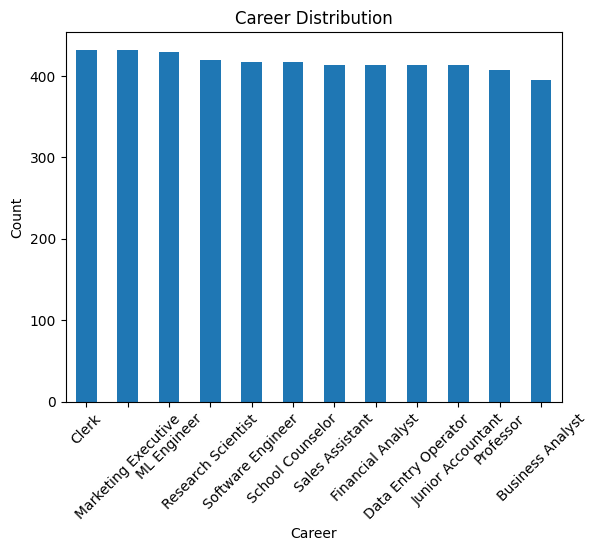

In [ ]:
import matplotlib.pyplot as plt

df["Recommended Career"].value_counts().plot(kind='bar')
plt.title("Career Distribution")
plt.xlabel("Career")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from collections import Counter

all_skills = []

for skills in df["Skills"]:
    all_skills.extend([s.strip() for s in skills.split(",")])

skill_counts = Counter(all_skills)

print(skill_counts.most_common(10))

[('Python', 1031), ('Accounting', 1013), ('Data Analysis', 1007), ('MS Office', 1005), ('Financial Analysis', 997), ('SQL', 993), ('Marketing', 992), ('Counseling', 986), ('Communication', 970), ('Machine Learning', 951)]


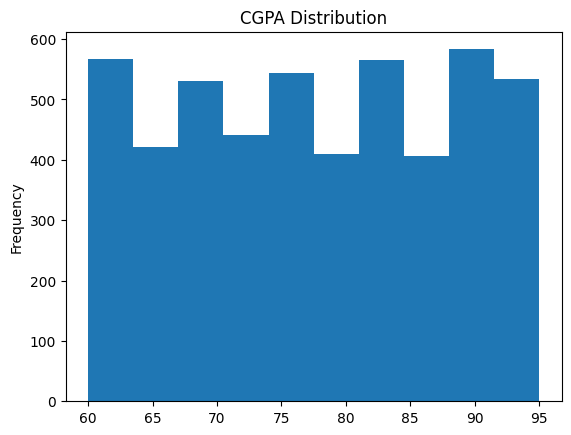

In [ ]:
df["CGPA/Percentage"].plot(kind='hist', bins=10)
plt.title("CGPA Distribution")
plt.show()

In [ ]:
pd.crosstab(df["Education Level"], df["Recommended Career"])

Recommended Career,Business Analyst,Clerk,Data Entry Operator,Financial Analyst,Junior Accountant,ML Engineer,Marketing Executive,Professor,Research Scientist,Sales Assistant,School Counselor,Software Engineer
Education Level,,,,,,,,,,,,
Bachelor's,77,106,80,79,80,93,91,90,75,79,84,87
Intermediate,91,85,79,86,81,84,84,84,67,71,87,74
Master's,78,87,86,82,77,100,86,71,112,73,88,88
Matric,86,68,90,79,93,67,81,84,88,100,85,93
PhD,63,86,78,87,82,85,90,78,77,90,73,75


In [ ]:
pd.crosstab(df["Specialization"], df["Recommended Career"])

Recommended Career,Business Analyst,Clerk,Data Entry Operator,Financial Analyst,Junior Accountant,ML Engineer,Marketing Executive,Professor,Research Scientist,Sales Assistant,School Counselor,Software Engineer
Specialization,,,,,,,,,,,,
Arts,46,54,36,54,53,46,59,59,52,47,49,49
Business,54,40,60,50,58,61,53,52,41,53,61,51
Commerce,48,41,65,43,63,54,50,43,45,55,50,44
Computer Science,59,60,55,50,36,54,44,44,58,49,51,49
Engineering,35,69,55,55,47,52,68,47,57,61,54,68
Finance,60,59,50,53,49,52,67,52,52,50,64,51
Psychology,45,64,52,66,63,56,45,55,62,51,44,54
Science,48,45,40,42,44,54,46,55,52,47,44,51


clean data

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Lowercase skills
df["Skills"] = df["Skills"].str.lower()

df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"counseling, ms office, machine learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"accounting, ms office",AWS Certified,67,Software Engineer
2,Master's,Business,"accounting, sql, data analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,communication,0,75,Clerk
4,Matric,Business,data analysis,Tally ERP,83,Sales Assistant


In [ ]:
def extract_skills(skill_text):
    return [s.strip() for s in skill_text.split(",")]

df["Skill_List"] = df["Skills"].apply(extract_skills)

df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career,Skill_List
0,Bachelor's,Finance,"counseling, ms office, machine learning",Tally ERP,67,Business Analyst,"[counseling, ms office, machine learning]"
1,Intermediate,Science,"accounting, ms office",AWS Certified,67,Software Engineer,"[accounting, ms office]"
2,Master's,Business,"accounting, sql, data analysis",Mental Health Basics,90,Financial Analyst,"[accounting, sql, data analysis]"
3,Bachelor's,Computer Science,communication,0,75,Clerk,[communication]
4,Matric,Business,data analysis,Tally ERP,83,Sales Assistant,[data analysis]


In [ ]:
df["Skills_Text"] = df["Skill_List"].apply(lambda x: " ".join(x))
df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career,Skill_List,Skills_Text
0,Bachelor's,Finance,"counseling, ms office, machine learning",Tally ERP,67,Business Analyst,"[counseling, ms office, machine learning]",counseling ms office machine learning
1,Intermediate,Science,"accounting, ms office",AWS Certified,67,Software Engineer,"[accounting, ms office]",accounting ms office
2,Master's,Business,"accounting, sql, data analysis",Mental Health Basics,90,Financial Analyst,"[accounting, sql, data analysis]",accounting sql data analysis
3,Bachelor's,Computer Science,communication,0,75,Clerk,[communication],communication
4,Matric,Business,data analysis,Tally ERP,83,Sales Assistant,[data analysis],data analysis


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_edu = LabelEncoder()
le_spec = LabelEncoder()
le_career = LabelEncoder()

df["Education Level"] = le_edu.fit_transform(df["Education Level"])
df["Specialization"] = le_spec.fit_transform(df["Specialization"])
df["Recommended Career"] = le_career.fit_transform(df["Recommended Career"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
skills_matrix = tfidf.fit_transform(df["Skills_Text"])

In [ ]:
import numpy as np

X_other = df[["Education Level", "Specialization", "CGPA/Percentage"]].values

X = np.hstack((skills_matrix.toarray(), X_other))

y = df["Recommended Career"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

print("Model trained successfully ✅")

Model trained successfully ✅


In [ ]:
def predict_career(user_skills, edu, spec, cgpa):

    user_skills = user_skills.lower()

    skill_vec = tfidf.transform([user_skills]).toarray()

    edu_val = le_edu.transform([edu])[0]
    spec_val = le_spec.transform([spec])[0]

    user_features = np.hstack((skill_vec, [[edu_val, spec_val, cgpa]]))

    pred = model.predict(user_features)

    return le_career.inverse_transform(pred)[0]

In [ ]:
def get_skill_gap(user_skills, target_role):

    role_skills = {
        "Data Analyst": ["python", "sql", "power bi", "excel"],
        "Business Analyst": ["excel", "sql", "power bi"],
        "Supply Chain Analyst": ["excel", "sql", "analytics"]
    }

    user_set = set(user_skills.lower().split(", "))
    required = set(role_skills.get(target_role, []))

    return list(required - user_set)

In [ ]:
career = predict_career(
    user_skills="python",
    edu="Bachelor's",
    spec="Computer Science",
    cgpa=75
)

gap = get_skill_gap("python, sql", career)

print("🎯 Recommended Career:", career)
print("📉 Skill Gap:", gap)

🎯 Recommended Career: Clerk
📉 Skill Gap: []
